In [1]:
#%pip install -q implicit mlflow scikit-learn scipy matplotlib seaborn umap-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2

In [2]:
from __future__ import annotations

import hashlib
import logging
import os
import pickle
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import mlflow
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from implicit.als import AlternatingLeastSquares
from implicit.evaluation import mean_average_precision_at_k, ndcg_at_k
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

SEED = 42
np.random.seed(SEED)

ROOT      = Path("/content")
DATA_DIR  = ROOT / "data";  DATA_DIR.mkdir(exist_ok=True)
MODEL_DIR = ROOT / "models"; MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / "als_model.pkl"

print("Imports complete")
print(f"   ROOT → {ROOT}")


/usr/local/lib/python3.12/dist-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of 'libcublas.so.13: cannot open shared object file: No such file or directory'
  warnings.warn(


Imports complete
   ROOT → /content


In [3]:
@dataclass
class ALSConfig:
    factors:         int   = 64
    regularization:  float = 0.01
    iterations:      int   = 20
    confidence_alpha: float = 40.0

    n_users:   int   = 10_000
    n_items:   int   = 1_000
    n_ints:    int   = 500_000
    test_size: float = 0.2
    random_seed: int = 42

    experiment_name: str = "recsys-collaborative-filtering"

    model_path: Path = field(default_factory=lambda: MODEL_PATH)


CFG = ALSConfig()
print(CFG)


ALSConfig(factors=64, regularization=0.01, iterations=20, confidence_alpha=40.0, n_users=10000, n_items=1000, n_ints=500000, test_size=0.2, random_seed=42, experiment_name='recsys-collaborative-filtering', model_path=PosixPath('/content/models/als_model.pkl'))


In [4]:
def generate_interactions(cfg: ALSConfig) -> pd.DataFrame:
    rng = np.random.default_rng(cfg.random_seed)
    N, M, K = cfg.n_users, cfg.n_items, cfg.n_ints

    ranks         = np.arange(1, M + 1, dtype=np.float64)
    item_pop      = (1.0 / ranks) ** 0.7
    item_pop     /= item_pop.sum()

    N_CLUSTERS = 8
    cluster_size  = M // N_CLUSTERS
    user_cluster  = rng.integers(0, N_CLUSTERS, size=N)

    rows, cols, counts = [], [], []

    for _ in range(K):
        u = rng.integers(0, N)
        c = user_cluster[u]

        if rng.random() < 0.60:
            lo  = c * cluster_size
            hi  = lo + cluster_size
            sub = item_pop[lo:hi]
            sub = sub / sub.sum()
            i   = rng.choice(range(lo, hi), p=sub)
        else:
            i = rng.choice(M, p=item_pop)

        rows.append(u)
        cols.append(i)
        counts.append(int(rng.poisson(2) + 1))

    df = (
        pd.DataFrame({"user_id": rows, "item_id": cols,
                      "interaction_count": counts})
        .groupby(["user_id", "item_id"], as_index=False)["interaction_count"]
        .sum()
    )

    cluster_map = dict(enumerate(user_cluster))
    df["user_cluster"] = df["user_id"].map(cluster_map)

    print(f" Interactions : {len(df):,}")
    print(f"   Unique users : {df.user_id.nunique():,}")
    print(f"   Unique items : {df.item_id.nunique():,}")
    print(f"   Avg count/row: {df.interaction_count.mean():.2f}")
    return df


df = generate_interactions(CFG)
df.to_parquet(DATA_DIR / "interactions.parquet", index=False)
df.head(8)


 Interactions : 446,931
   Unique users : 10,000
   Unique items : 1,000
   Avg count/row: 3.36


,user_id,item_id,interaction_count,user_cluster
0,0,0,2,0
1,0,1,7,0
2,0,2,9,0
3,0,4,8,0
4,0,5,4,0
5,0,6,2,0
6,0,8,3,0
7,0,11,2,0


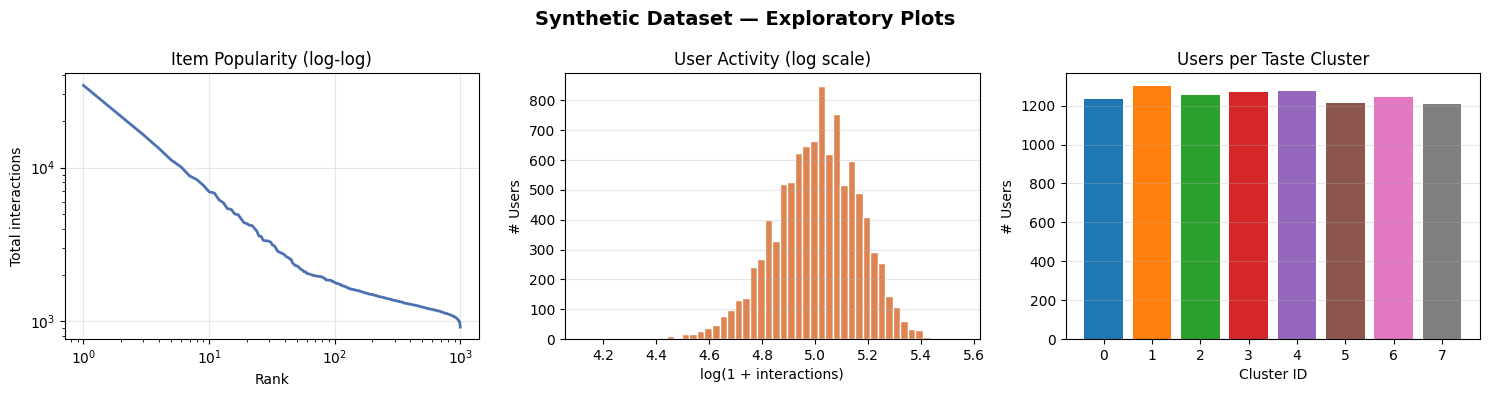

EDA plot saved


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Synthetic Dataset — Exploratory Plots", fontsize=14, fontweight="bold")

ax = axes[0]
item_counts = df.groupby("item_id")["interaction_count"].sum().sort_values(ascending=False)
ax.loglog(range(1, len(item_counts)+1), item_counts.values, lw=2, color="#4C72B0")
ax.set(title="Item Popularity (log-log)", xlabel="Rank", ylabel="Total interactions")
ax.grid(True, alpha=0.3)

ax = axes[1]
user_activity = df.groupby("user_id")["interaction_count"].sum()
ax.hist(np.log1p(user_activity), bins=50, color="#DD8452", edgecolor="white", lw=0.4)
ax.set(title="User Activity (log scale)", xlabel="log(1 + interactions)", ylabel="# Users")
ax.grid(True, alpha=0.3, axis="y")

ax = axes[2]
cluster_sizes = df.drop_duplicates("user_id")["user_cluster"].value_counts().sort_index()
ax.bar(cluster_sizes.index, cluster_sizes.values, color=plt.cm.tab10.colors[:len(cluster_sizes)])
ax.set(title="Users per Taste Cluster", xlabel="Cluster ID", ylabel="# Users")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(DATA_DIR / "eda.png", dpi=130, bbox_inches="tight")
plt.show()
print("EDA plot saved")


In [6]:
def build_id_mappings(df: pd.DataFrame):
    unique_users = sorted(df["user_id"].unique())
    unique_items = sorted(df["item_id"].unique())
    user2idx = {u: i for i, u in enumerate(unique_users)}
    idx2user = {i: u for u, i in user2idx.items()}
    item2idx = {v: i for i, v in enumerate(unique_items)}
    idx2item = {i: v for v, i in item2idx.items()}
    print(f"Mappings — {len(user2idx):,} users, {len(item2idx):,} items")
    return user2idx, idx2user, item2idx, idx2item


def build_sparse_matrix(
    df: pd.DataFrame,
    user2idx: dict,
    item2idx: dict,
    alpha: float = 40.0,
    count_col: str = "interaction_count",
) -> sp.csr_matrix:

    if count_col not in df.columns:
        df = df.copy(); df[count_col] = 1.0

    rows = df["user_id"].map(user2idx).values
    cols = df["item_id"].map(item2idx).values
    data = df[count_col].astype(np.float32).values

    n_u, n_i = len(user2idx), len(item2idx)
    mat = sp.coo_matrix((data, (rows, cols)), shape=(n_u, n_i)).tocsr()

    mat.data = 1.0 + alpha * mat.data

    density = 100.0 * mat.nnz / (n_u * n_i)
    print(f"Sparse matrix — shape: {mat.shape}, nnz: {mat.nnz:,}, "
          f"density: {density:.3f}%")
    return mat


def train_test_split_sparse(mat: sp.csr_matrix, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    coo = mat.tocoo()
    n   = len(coo.data)
    idx = rng.choice(n, size=int(n * test_size), replace=False)
    mask = np.zeros(n, dtype=bool); mask[idx] = True

    def _build(sel):
        return sp.coo_matrix(
            (coo.data[sel], (coo.row[sel], coo.col[sel])), shape=mat.shape
        ).tocsr()

    tr, te = _build(~mask), _build(mask)
    print(f" Train nnz: {tr.nnz:,}  |  Test nnz: {te.nnz:,}")
    return tr, te


user2idx, idx2user, item2idx, idx2item = build_id_mappings(df)
user_item_full = build_sparse_matrix(df, user2idx, item2idx, alpha=CFG.confidence_alpha)
train_mat, test_mat = train_test_split_sparse(
    user_item_full, CFG.test_size, CFG.random_seed
)


Mappings — 10,000 users, 1,000 items
Sparse matrix — shape: (10000, 1000), nnz: 446,931, density: 4.469%
 Train nnz: 357,545  |  Test nnz: 89,386


In [7]:
als = AlternatingLeastSquares(
    factors=CFG.factors,
    regularization=CFG.regularization,
    iterations=CFG.iterations,
    calculate_training_loss=True,
    random_state=CFG.random_seed
)
als.fit(train_mat)
if hasattr(als, "loss_") and als.loss_:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(range(1, len(als.loss_)+1), als.loss_, marker="o", color="#4C72B0", lw=2)
    ax.set(title="ALS Training Loss per Iteration",
           xlabel="Iteration", ylabel="Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(" Loss history not available for this implicit version.")

  0%|          | 0/20 [00:00<?, ?it/s]

 Loss history not available for this implicit version.


In [8]:
def evaluate_at_k(model, train, test, k_values=(5, 10, 20, 50)):
    rows = []
    for k in k_values:
        map_k  = mean_average_precision_at_k(model, train, test, K=k, num_threads=0)
        ndcg_k = ndcg_at_k(model, train, test, K=k, num_threads=0)
        rows.append({"k": k, "MAP@k": round(float(map_k), 5),
                     "NDCG@k": round(float(ndcg_k), 5)})
    return pd.DataFrame(rows)


metrics_df = evaluate_at_k(als, train_mat, test_mat)
display(metrics_df.style.background_gradient(cmap="YlGn").format("{:.5f}",
        subset=["MAP@k", "NDCG@k"]))


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,k,MAP@k,NDCG@k
0,5,0.02415,0.04983
1,10,0.01979,0.05603
2,20,0.02606,0.08690
3,50,0.03752,0.14831


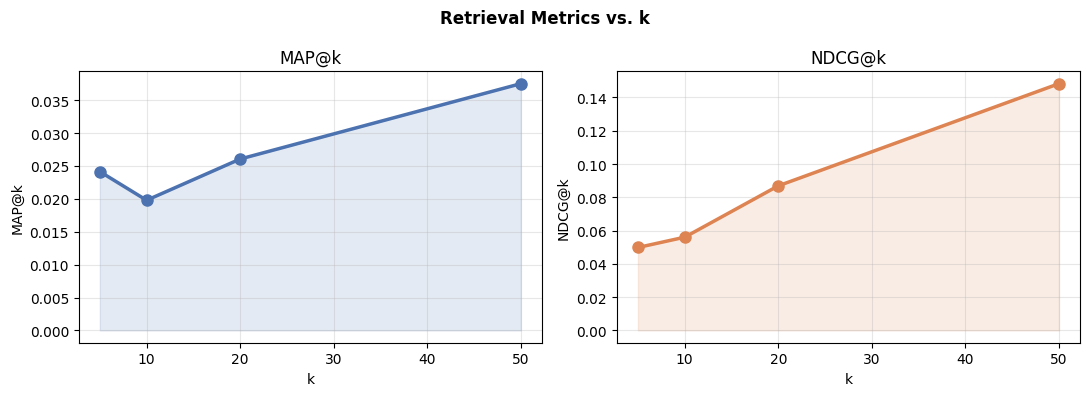

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Retrieval Metrics vs. k", fontweight="bold")

for ax, col, color in zip(axes, ["MAP@k", "NDCG@k"], ["#4C72B0", "#DD8452"]):
    ax.plot(metrics_df["k"], metrics_df[col], marker="o", lw=2.5,
            color=color, markersize=8)
    ax.fill_between(metrics_df["k"], metrics_df[col], alpha=0.15, color=color)
    ax.set(title=col, xlabel="k", ylabel=col)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "metrics.png", dpi=130, bbox_inches="tight")
plt.show()


In [10]:
def _popular_fallback(n: int) -> List[dict]:
    """Cold-start: return globally most popular items."""
    pop = np.array(train_mat.sum(axis=0)).flatten()
    idxs = np.argsort(pop)[::-1][:n]
    return [{"item_id": int(idx2item[int(i)]), "score": float(pop[i]),
             "rank": r+1, "algorithm": "popularity_fallback"}
            for r, i in enumerate(idxs)]


def get_recommendations(user_id: int, n: int = 10,
                         filter_already_liked: bool = True) -> List[dict]:
    if user_id not in user2idx:
        print(f" user {user_id} unseen → popularity fallback")
        return _popular_fallback(n)

    u_idx = user2idx[user_id]
    ids, scores = als.recommend(
        userid=u_idx,
        user_items=train_mat[u_idx],
        N=n,
        filter_already_liked_items=filter_already_liked,
    )
    return [{"item_id": int(idx2item[int(i)]), "score": float(s),
             "rank": r+1, "algorithm": "collaborative_als"}
            for r, (i, s) in enumerate(zip(ids, scores))]


def get_similar_items(item_id: int, n: int = 10) -> List[dict]:

    if item_id not in item2idx:
        return []
    i_idx = item2idx[item_id]
    ids, scores = als.similar_items(itemid=i_idx, N=n+1)
    out = []
    for i, s in zip(ids, scores):
        ext = int(idx2item[int(i)])
        if ext == item_id: continue
        out.append({"item_id": ext, "score": float(s), "rank": len(out)+1})
        if len(out) == n: break
    return out

sample_uid = list(user2idx.keys())[0]
recs = get_recommendations(sample_uid, n=10)
print(f"\nTop-10 for user {sample_uid}")
display(pd.DataFrame(recs))

sample_iid = list(item2idx.keys())[7]
sims = get_similar_items(sample_iid, n=8)
print(f"\nItems similar to item {sample_iid}")
display(pd.DataFrame(sims))

print("\n Cold-start (unseen user 999999):")
display(pd.DataFrame(get_recommendations(999999, n=5)))



Top-10 for user 0


,item_id,score,rank,algorithm
0,22,1.736560,1,collaborative_als
1,35,1.467800,2,collaborative_als
2,107,1.351437,3,collaborative_als
3,53,1.223535,4,collaborative_als
4,255,1.196258,5,collaborative_als
5,66,1.176006,6,collaborative_als
6,248,1.140254,7,collaborative_als
7,47,1.116995,8,collaborative_als
8,209,1.094465,9,collaborative_als
9,84,1.085616,10,collaborative_als



Items similar to item 7


,item_id,score,rank
0,3,0.998155,1
1,5,0.998098,2
2,4,0.997984,3
3,6,0.997963,4
4,2,0.997890,5
5,1,0.997680,6
6,0,0.997522,7
7,10,0.996862,8



 Cold-start (unseen user 999999):
 user 999999 unseen → popularity fallback


,item_id,score,rank,algorithm
0,0,1118103.0,1,popularity_fallback
1,1,686201.0,2,popularity_fallback
2,2,530100.0,3,popularity_fallback
3,3,436454.0,4,popularity_fallback
4,4,356752.0,5,popularity_fallback


Projecting with UMAP…


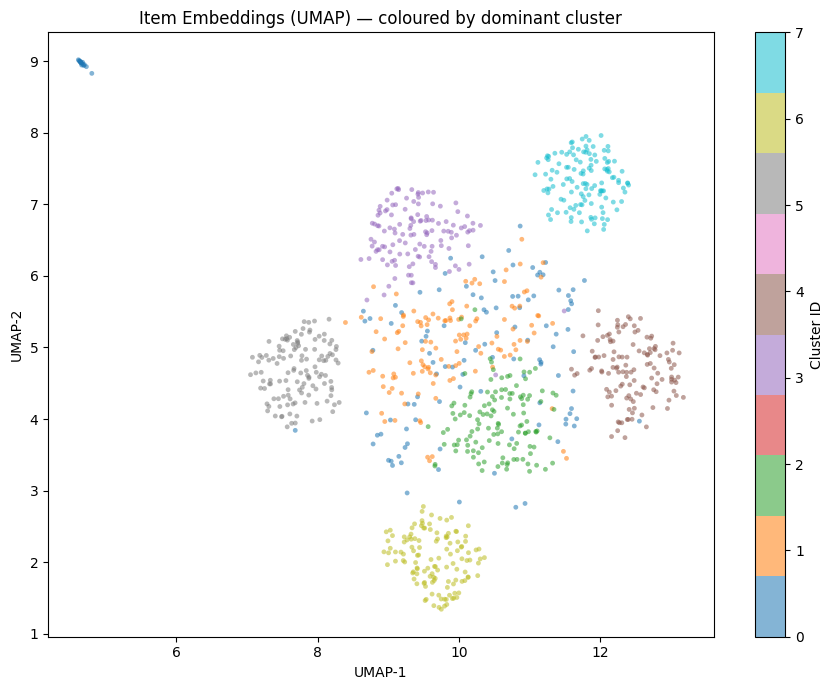

Embedding plot saved


In [11]:
item_vecs = normalize(als.item_factors, axis=1)

try:
    from umap import UMAP
    reducer = UMAP(n_components=2, random_state=SEED, n_neighbors=20,
                   min_dist=0.1, metric="cosine")
    method_name = "UMAP"
except ImportError:
    reducer = PCA(n_components=2, random_state=SEED)
    method_name = "PCA"

print(f"Projecting with {method_name}…")
emb2d = reducer.fit_transform(item_vecs)
item_cluster = (
    df.groupby("item_id")["user_cluster"].agg(lambda x: x.mode()[0])
)
clusters = np.array([item_cluster.get(idx2item[i], -1)
                     for i in range(len(idx2item))])

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    emb2d[:, 0], emb2d[:, 1],
    c=clusters, cmap="tab10", alpha=0.55, s=12, linewidths=0,
)
ax.set(title=f"Item Embeddings ({method_name}) — coloured by dominant cluster",
       xlabel=f"{method_name}-1", ylabel=f"{method_name}-2")
plt.colorbar(scatter, ax=ax, label="Cluster ID")
plt.tight_layout()
plt.savefig(DATA_DIR / "embeddings.png", dpi=130, bbox_inches="tight")
plt.show()
print("Embedding plot saved")


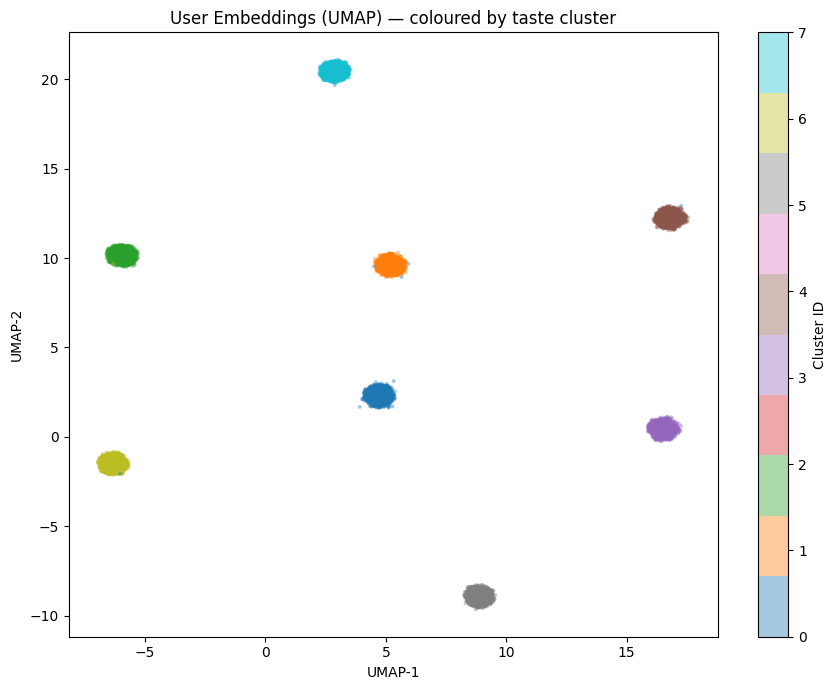

In [12]:
user_vecs   = normalize(als.user_factors, axis=1)
user_emb2d  = reducer.fit_transform(user_vecs) if method_name == "PCA" \
              else UMAP(n_components=2, random_state=SEED,
                        metric="cosine").fit_transform(user_vecs)

uid_to_cluster = dict(zip(df["user_id"], df["user_cluster"]))
u_clusters = np.array([uid_to_cluster.get(idx2user[i], -1)
                       for i in range(len(idx2user))])

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(user_emb2d[:, 0], user_emb2d[:, 1],
                c=u_clusters, cmap="tab10", alpha=0.4, s=8, linewidths=0)
ax.set(title=f"User Embeddings ({method_name}) — coloured by taste cluster",
       xlabel=f"{method_name}-1", ylabel=f"{method_name}-2")
plt.colorbar(sc, ax=ax, label="Cluster ID")
plt.tight_layout()
plt.show()


 Catalogue coverage across 500 users: 98.5%


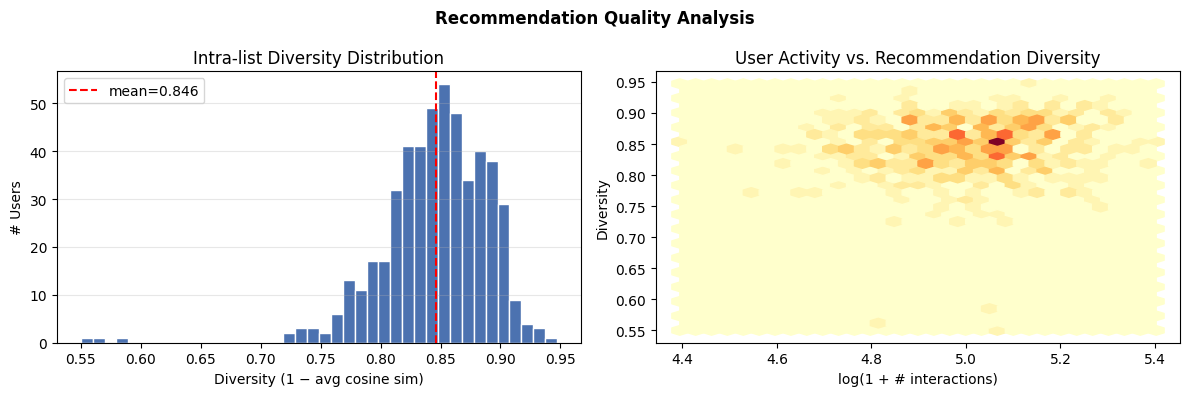

Avg intra-list diversity: 0.8460


In [13]:
N_SAMPLE = 500

sample_users = np.random.choice(list(user2idx.keys()), N_SAMPLE, replace=False)
all_recs = {}
for uid in sample_users:
    all_recs[uid] = [r["item_id"] for r in get_recommendations(uid, n=10)]

all_items_rec = {i for recs in all_recs.values() for i in recs}
coverage = 100.0 * len(all_items_rec) / CFG.n_items
print(f" Catalogue coverage across {N_SAMPLE} users: {coverage:.1f}%")

item_norms = normalize(als.item_factors, axis=1)

def intra_diversity(item_ids: list) -> float:
    if len(item_ids) < 2: return 0.0
    idxs = [item2idx[i] for i in item_ids if i in item2idx]
    vecs = item_norms[idxs]
    sims = vecs @ vecs.T
    n = len(vecs)
    return float(1 - (sims.sum() - n) / (n * (n - 1) + 1e-9))

diversities = [intra_diversity(v) for v in all_recs.values()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Recommendation Quality Analysis", fontweight="bold")

pop_ranks = [
    np.where(item_pop_sorted == item2idx.get(i, -1))[0][0]
    if item2idx.get(i, -1) in item_pop_sorted else 0
    for recs in list(all_recs.values())[:100]
    for i in recs
] if False else []
axes[0].hist(diversities, bins=40, color="#4C72B0", edgecolor="white", lw=0.4)
axes[0].axvline(np.mean(diversities), color="red", ls="--", lw=1.5,
                label=f"mean={np.mean(diversities):.3f}")
axes[0].set(title="Intra-list Diversity Distribution",
            xlabel="Diversity (1 − avg cosine sim)", ylabel="# Users")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

user_act = df.groupby("user_id")["interaction_count"].sum()
acts, divs = [], []
for uid, recs_list in list(all_recs.items())[:N_SAMPLE]:
    acts.append(np.log1p(user_act.get(uid, 0)))
    divs.append(intra_diversity(recs_list))
axes[1].hexbin(acts, divs, gridsize=30, cmap="YlOrRd")
axes[1].set(title="User Activity vs. Recommendation Diversity",
            xlabel="log(1 + # interactions)", ylabel="Diversity")

plt.tight_layout()
plt.savefig(DATA_DIR / "diversity.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Avg intra-list diversity: {np.mean(diversities):.4f}")


In [14]:
MLFLOW_DB     = ROOT / "mlflow.db"
TRACKING_URI = f"sqlite:///{MLFLOW_DB}"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(CFG.experiment_name)

train_time = 0.0 # Placeholder for training time

with mlflow.start_run(run_name=f"als_f{CFG.factors}_i{CFG.iterations}") as run:

    mlflow.log_params({
        "factors":          CFG.factors,
        "regularization":   CFG.regularization,
        "iterations":       CFG.iterations,
        "confidence_alpha": CFG.confidence_alpha,
        "n_users":          CFG.n_users,
        "n_items":          CFG.n_items,
        "n_interactions":   len(df),
        "test_size":        CFG.test_size,
    })

    row10 = metrics_df[metrics_df.k == 10].iloc[0]
    mlflow.log_metrics({
        "map_at_10":          row10["MAP@k"],
        "ndcg_at_10":         row10["NDCG@k"],
        "train_time_sec":     round(train_time, 2),
        "catalogue_coverage": round(coverage, 2),
        "avg_diversity":      round(float(np.mean(diversities)), 4),
    })

    with open(MODEL_PATH, "wb") as f:
        pickle.dump({
            "model":           als,
            "user2idx":        user2idx,
            "idx2user":        idx2user,
            "item2idx":        item2idx,
            "idx2item":        idx2item,
            "user_item_train": train_mat,
            "config":          CFG,
        }, f, protocol=pickle.HIGHEST_PROTOCOL)

    mlflow.log_artifact(str(MODEL_PATH),                  artifact_path="model")
    mlflow.log_artifact(str(DATA_DIR / "metrics.png"),    artifact_path="plots")
    mlflow.log_artifact(str(DATA_DIR / "embeddings.png"), artifact_path="plots")
    mlflow.log_artifact(str(DATA_DIR / "diversity.png"),  artifact_path="plots")

    print(f" MLflow run: {run.info.run_id}")
    print(f"   DB: {MLFLOW_DB}")
    print(f"   UI: mlflow ui --backend-store-uri {TRACKING_URI} --port 5000")

2026/06/23 18:11:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/23 18:11:32 INFO mlflow.store.db.utils: Updating database tables
2026/06/23 18:11:37 INFO mlflow.tracking.fluent: Experiment with name 'recsys-collaborative-filtering' does not exist. Creating a new experiment.


 MLflow run: 97c8c48fdd484529a8aca3619ffa5aa0
   DB: /content/mlflow.db
   UI: mlflow ui --backend-store-uri sqlite:////content/mlflow.db --port 5000


In [15]:
with open(MODEL_PATH, "rb") as f:
    payload = pickle.load(f)

als2      = payload["model"]
u2i2      = payload["user2idx"]
i2u2      = payload["idx2user"]
it2i2     = payload["item2idx"]
i2it2     = payload["idx2item"]
train2    = payload["user_item_train"]

test_uid  = list(user2idx.keys())[42]
test_idx  = user2idx[test_uid]

ids1, sc1 = als.recommend(test_idx,  train_mat[test_idx],  N=5,
                           filter_already_liked_items=True)
ids2, sc2 = als2.recommend(u2i2[test_uid], train2[u2i2[test_uid]], N=5,
                            filter_already_liked_items=True)

match = list(ids1) == list(ids2)
print(f" Reload round-trip {'PASSED ' if match else 'FAILED ✗'}")
print(f"   Model path : {MODEL_PATH}")
print(f"   File size  : {MODEL_PATH.stat().st_size / 1e6:.1f} MB")


 Reload round-trip PASSED 
   Model path : /content/models/als_model.pkl
   File size  : 6.1 MB


In [16]:
import hashlib
import json
import pickle
import sqlite3
import time
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from enum import Enum
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np

ROOT              = Path("/content")
MODEL_DIR         = ROOT / "models"
DB_PATH           = ROOT / "data" / "events.db"
ALS_MODEL_PATH    = MODEL_DIR / "als_model.pkl"
FAISS_INDEX_PATH  = MODEL_DIR / "faiss_index.bin"
EMBEDDINGS_PATH   = MODEL_DIR / "item_embeddings.npy"
CONTENT_META_PATH = MODEL_DIR / "content_meta.pkl"


class Variant(str, Enum):
    CONTROL   = "control"    # Variant A — ALS
    TREATMENT = "treatment"  # Variant B — content-based

class ExperimentStatus(str, Enum):
    RUNNING  = "running"
    PAUSED   = "paused"
    FINISHED = "finished"


def assign_variant(user_id: int, experiment_id: str, traffic_pct: int = 50) -> Variant:
    """
    SHA-256(experiment_id:user_id) % 100 → bucket
    bucket < traffic_pct → TREATMENT, else → CONTROL
    Same inputs always produce the same variant.
    """
    raw    = f"{experiment_id}:{user_id}".encode()
    bucket = int(hashlib.sha256(raw).hexdigest(), 16) % 100
    return Variant.TREATMENT if bucket < traffic_pct else Variant.CONTROL


@dataclass
class ExperimentConfig:
    experiment_id:    str
    description:      str              = ""
    traffic_pct:      int              = 50
    status:           ExperimentStatus = ExperimentStatus.RUNNING
    created_at:       str              = ""
    min_sample_size:  int              = 1_000
    target_metric:    str              = "ctr"

    def __post_init__(self):
        if not self.created_at:
            self.created_at = datetime.now(timezone.utc).isoformat()

    def save(self, path: Path) -> None:
        d = asdict(self)
        d["status"] = self.status.value
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(d, indent=2))
        print(f"Config saved → {path}")

    @classmethod
    def load(cls, path: Path) -> "ExperimentConfig":
        d = json.loads(path.read_text())
        d["status"] = ExperimentStatus(d["status"])
        return cls(**d)


class EventLogger:

    def __init__(self, db_path: Path = DB_PATH):
        self.db_path = Path(db_path)
        self.db_path.parent.mkdir(parents=True, exist_ok=True)
        self._init_db()

    def _conn(self):
        c = sqlite3.connect(str(self.db_path))
        c.execute("PRAGMA journal_mode=WAL")
        return c

    def _init_db(self):
        with self._conn() as c:
            c.execute("""
                CREATE TABLE IF NOT EXISTS events (
                    id            INTEGER PRIMARY KEY AUTOINCREMENT,
                    experiment_id TEXT    NOT NULL,
                    user_id       INTEGER NOT NULL,
                    item_id       INTEGER NOT NULL,
                    variant       TEXT    NOT NULL,
                    event_type    TEXT    NOT NULL,
                    rank          INTEGER,
                    timestamp     REAL    NOT NULL
                )""")
            c.execute("CREATE INDEX IF NOT EXISTS idx_exp ON events(experiment_id, variant)")

    def log_impression(self, experiment_id, user_id, recommendations, variant: Variant):
        ts   = time.time()
        rows = [(experiment_id, user_id, r["item_id"],
                 variant.value, "impression", r.get("rank", i+1), ts)
                for i, r in enumerate(recommendations)]
        with self._conn() as c:
            c.executemany(
                "INSERT INTO events(experiment_id,user_id,item_id,variant,event_type,rank,timestamp)"
                " VALUES(?,?,?,?,?,?,?)", rows)

    def log_click(self, experiment_id, user_id, item_id, variant: Variant, rank=None):
        with self._conn() as c:
            c.execute(
                "INSERT INTO events(experiment_id,user_id,item_id,variant,event_type,rank,timestamp)"
                " VALUES(?,?,?,?,?,?,?)",
                (experiment_id, user_id, item_id, variant.value, "click", rank, time.time()))

    def get_counts(self, experiment_id, variant: Optional[Variant] = None) -> Dict:
        q, p = "SELECT event_type,COUNT(*) FROM events WHERE experiment_id=?", [experiment_id]
        if variant:
            q += " AND variant=?"; p.append(variant.value)
        q += " GROUP BY event_type"
        with self._conn() as c:
            rows = c.execute(q, p).fetchall()
        counts = {"impression": 0, "click": 0}
        for etype, n in rows:
            counts[etype] = n
        return counts


class ABRouter:
    def __init__(self, config: ExperimentConfig, interactions_df=None):
        self.config           = config
        self.interactions_df  = interactions_df
        self.logger           = EventLogger()
        self._als_payload     = None
        self._content_tuple   = None

    def _get_als(self):
        if self._als_payload is None:
            with open(ALS_MODEL_PATH, "rb") as f:
                self._als_payload = pickle.load(f)
            print(" ALS model loaded")
        return self._als_payload

    def _get_content(self):
        if self._content_tuple is None:
            import faiss
            idx  = faiss.read_index(str(FAISS_INDEX_PATH)); idx.nprobe = 8
            emb  = np.load(str(EMBEDDINGS_PATH))
            with open(CONTENT_META_PATH, "rb") as f:
                meta = pickle.load(f)
            self._content_tuple = (idx, emb, meta)
            print(" Content model loaded")
        return self._content_tuple

    def get_variant(self, user_id: int) -> Variant:
        return assign_variant(user_id, self.config.experiment_id, self.config.traffic_pct)

    def recommend(self, user_id: int, n: int = 10, log_impression: bool = True) -> Dict:
        variant = self.get_variant(user_id)
        recs    = (self._rec_als(user_id, n) if variant == Variant.CONTROL
                   else self._rec_content(user_id, n))
        if log_impression:
            self.logger.log_impression(self.config.experiment_id, user_id, recs, variant)
        return {"experiment_id": self.config.experiment_id,
                "user_id": user_id, "variant": variant.value, "recommendations": recs}

    def log_click(self, user_id: int, item_id: int, rank: Optional[int] = None):
        self.logger.log_click(self.config.experiment_id, user_id, item_id,
                              self.get_variant(user_id), rank)

    def experiment_stats(self) -> Dict:
        stats = {}
        for v in Variant:
            c = self.logger.get_counts(self.config.experiment_id, v)
            stats[v.value] = {"impressions": c["impression"], "clicks": c["click"],
                              "ctr": round(c["click"]/c["impression"], 6)
                                     if c["impression"] else 0.0}
        stats.update({"experiment_id": self.config.experiment_id,
                       "status": self.config.status.value,
                       "min_sample": self.config.min_sample_size})
        return stats

    def _rec_als(self, user_id: int, n: int) -> List[Dict]:
        p = self._get_als()
        model, u2i, i2item, mat = p["model"], p["user2idx"], p["idx2item"], p["user_item_train"]
        if user_id not in u2i:
            pop  = np.array(mat.sum(axis=0)).flatten()
            top  = np.argsort(pop)[::-1][:n]
            return [{"item_id": int(i2item[int(i)]), "score": float(pop[i]),
                     "rank": r+1, "algorithm": "als_cold_start"} for r, i in enumerate(top)]
        uid  = u2i[user_id]
        ids, scores = model.recommend(uid, mat[uid], N=n, filter_already_liked_items=True)
        return [{"item_id": int(i2item[int(i)]), "score": float(s),
                 "rank": r+1, "algorithm": "collaborative_als"}
                for r, (i, s) in enumerate(zip(ids, scores))]

    def _rec_content(self, user_id: int, n: int) -> List[Dict]:
        idx, emb, meta = self._get_content()
        items_df, id2i = meta["items_df"], meta["item_id_to_idx"]

        profile = None
        if self.interactions_df is not None:
            ui = (self.interactions_df[self.interactions_df.user_id == user_id]
                  .sort_values("interaction_count", ascending=False).head(50))
            if not ui.empty:
                vecs, w = [], []
                for rank, (_, row) in enumerate(ui.iterrows()):
                    i = id2i.get(int(row.item_id))
                    if i is not None:
                        vecs.append(emb[i]); w.append(float(row.interaction_count) * 0.95**rank)
                if vecs:
                    w = np.array(w); w /= w.sum()
                    p = (np.stack(vecs) * w[:, None]).sum(axis=0)
                    norm = np.linalg.norm(p)
                    if norm > 1e-9:
                        profile = (p / norm).astype(np.float32)

        if profile is None:
            top = items_df.nlargest(n, "rating")
            return [{"item_id": int(r.item_id), "score": float(r.rating)/10,
                     "rank": i+1, "algorithm": "content_cold_start"}
                    for i, (_, r) in enumerate(top.iterrows())]

        interacted = set()
        if self.interactions_df is not None:
            interacted = set(self.interactions_df[
                self.interactions_df.user_id == user_id]["item_id"])

        D, I = idx.search(profile[np.newaxis, :], n + len(interacted) + 10)
        out, rank = [], 1
        for i, s in zip(I[0], D[0]):
            iid = int(items_df.iloc[int(i)]["item_id"])
            if iid in interacted: continue
            out.append({"item_id": iid, "score": float(s),
                        "rank": rank, "algorithm": "content_based"})
            rank += 1
            if rank > n: break
        return out


cfg = ExperimentConfig(experiment_id="exp_001",
                       description="ALS vs content-based 50/50",
                       traffic_pct=50)
cfg.save(ROOT / "experiments" / "exp_001.json")

print("\n── Variant assignment (10 sample users) ──")
for uid in [0, 1, 42, 99, 999, 1000, 5000, 7777, 9999, 10000]:
    v = assign_variant(uid, "exp_001", 50)
    print(f"  user {uid:6d} → {v.value}")

variants  = [assign_variant(u, "exp_001", 50) for u in range(10_000)]
treatment = sum(v == Variant.TREATMENT for v in variants)
print(f"\n── Split over 10 000 users ──")
print(f"  control   : {10_000-treatment:,} ({(10_000-treatment)/100:.1f}%)")
print(f"  treatment : {treatment:,} ({treatment/100:.1f}%)")

import tempfile
tmp = Path(tempfile.mktemp(suffix=".db"))
logger = EventLogger(tmp)
logger.log_impression("exp_001", 42, [{"item_id": i, "rank": i+1} for i in range(5)], Variant.CONTROL)
logger.log_click("exp_001", 42, item_id=2, variant=Variant.CONTROL, rank=2)
c = logger.get_counts("exp_001")
assert c["impression"] == 5 and c["click"] == 1
tmp.unlink()
print("\n── EventLogger ──")
print(f"  impressions: {c['impression']}  clicks: {c['click']}  ")

print("\n ab_router ready — instantiate ABRouter and call .recommend(user_id)")

Config saved → /content/experiments/exp_001.json

── Variant assignment (10 sample users) ──
  user      0 → control
  user      1 → control
  user     42 → treatment
  user     99 → control
  user    999 → control
  user   1000 → control
  user   5000 → control
  user   7777 → control
  user   9999 → treatment
  user  10000 → treatment

── Split over 10 000 users ──
  control   : 4,955 (49.5%)
  treatment : 5,045 (50.5%)

── EventLogger ──
  impressions: 5  clicks: 1  

 ab_router ready — instantiate ABRouter and call .recommend(user_id)


In [17]:
import sqlite3
import math
import numpy as np
from pathlib import Path
from dataclasses import dataclass
from typing import Optional
from scipy import stats

DB_PATH = Path("/content/data/events.db")


def get_ctr_data(experiment_id: str, variant: str) -> dict:
    """Pull impression and click counts for one variant from SQLite."""
    with sqlite3.connect(str(DB_PATH)) as conn:
        row = conn.execute(
            """SELECT
                 COUNT(CASE WHEN event_type='impression' THEN 1 END),
                 COUNT(CASE WHEN event_type='click'      THEN 1 END)
               FROM events
               WHERE experiment_id=? AND variant=?""",
            (experiment_id, variant),
        ).fetchone()
    impressions, clicks = row
    ctr = clicks / impressions if impressions > 0 else 0.0
    return {"variant": variant, "impressions": impressions,
            "clicks": clicks, "ctr": ctr}


@dataclass
class SignificanceResult:
    control_impressions:   int
    control_clicks:        int
    control_ctr:           float
    treatment_impressions: int
    treatment_clicks:      int
    treatment_ctr:         float
    absolute_lift:         float
    relative_lift_pct:     float
    z_statistic:           float
    p_value:               float
    ci_lower:              float
    ci_upper:              float
    is_significant:        bool
    alpha:                 float
    winner:                Optional[str]


def minimum_sample_size(
    baseline_ctr:  float,
    mde:           float = 0.05,
    alpha:         float = 0.05,
    power:         float = 0.80,
) -> int:
    """
    Two-proportion z-test sample size per variant.

    Parameters
    ----------
    baseline_ctr : float   Expected CTR of the control (e.g. 0.10 = 10%)
    mde          : float   Minimum detectable effect, relative (default 5%)
    alpha        : float   Type-I error rate (default 0.05)
    power        : float   1 - Type-II error rate (default 0.80)

    Returns
    -------
    int   Required impressions per variant
    """
    p1 = baseline_ctr
    p2 = baseline_ctr * (1 + mde)
    p_bar = (p1 + p2) / 2

    z_alpha = stats.norm.ppf(1 - alpha / 2)   # two-tailed
    z_beta  = stats.norm.ppf(power)

    numerator   = (z_alpha * math.sqrt(2 * p_bar * (1 - p_bar)) +
                   z_beta  * math.sqrt(p1 * (1-p1) + p2 * (1-p2))) ** 2
    denominator = (p2 - p1) ** 2

    return math.ceil(numerator / denominator)


def run_significance_test(
    experiment_id: str,
    alpha:         float = 0.05,
) -> SignificanceResult:

    ctrl = get_ctr_data(experiment_id, "control")
    trt  = get_ctr_data(experiment_id, "treatment")

    n1, x1 = ctrl["impressions"], ctrl["clicks"]
    n2, x2 = trt["impressions"],  trt["clicks"]
    p1, p2 = ctrl["ctr"], trt["ctr"]

    p_pool = (x1 + x2) / (n1 + n2) if (n1 + n2) > 0 else 0.0

    se = math.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2)) if (n1 > 0 and n2 > 0) else 0.0

    if se == 0:
        z, p = 0.0, 1.0
    else:
        z = (p2 - p1) / se
        p = float(2 * (1 - stats.norm.cdf(abs(z))))

    se_lift = math.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2) if (n1 > 0 and n2 > 0) else 0.0
    z_ci    = stats.norm.ppf(1 - alpha / 2)
    lift    = p2 - p1
    ci_lo   = lift - z_ci * se_lift
    ci_hi   = lift + z_ci * se_lift

    significant = p < alpha
    if significant:
        winner = "treatment" if p2 > p1 else "control"
    else:
        winner = None

    return SignificanceResult(
        control_impressions   = n1,
        control_clicks        = x1,
        control_ctr           = round(p1, 6),
        treatment_impressions = n2,
        treatment_clicks      = x2,
        treatment_ctr         = round(p2, 6),
        absolute_lift         = round(lift, 6),
        relative_lift_pct     = round((lift / p1 * 100) if p1 > 0 else 0.0, 2),
        z_statistic           = round(z, 4),
        p_value               = round(p, 6),
        ci_lower              = round(ci_lo, 6),
        ci_upper              = round(ci_hi, 6),
        is_significant        = significant,
        alpha                 = alpha,
        winner                = winner,
    )


def print_report(result: SignificanceResult) -> None:
    w = 48
    print("=" * w)
    print("A/B TEST SIGNIFICANCE REPORT")
    print("=" * w)
    print(f"{'':20s}  {'control':>10s}  {'treatment':>10s}")
    print("-" * w)
    print(f"{'Impressions':<20s}  {result.control_impressions:>10,}  {result.treatment_impressions:>10,}")
    print(f"{'Clicks':<20s}  {result.control_clicks:>10,}  {result.treatment_clicks:>10,}")
    print(f"{'CTR':<20s}  {result.control_ctr:>10.4%}  {result.treatment_ctr:>10.4%}")
    print("-" * w)
    print(f"Absolute lift    : {result.absolute_lift:+.4%}")
    print(f"Relative lift    : {result.relative_lift_pct:+.2f}%")
    print(f"95% CI on lift   : [{result.ci_lower:+.4%},  {result.ci_upper:+.4%}]")
    print(f"Z-statistic      : {result.z_statistic:.4f}")
    print(f"P-value          : {result.p_value:.6f}")
    print(f"Alpha            : {result.alpha}")
    print("-" * w)
    sig_label = "YES" if result.is_significant else "NO"
    print(f"Significant      : {sig_label}  (p {'<' if result.is_significant else '>='} {result.alpha})")
    print(f"Winner           : {result.winner or 'undecided'}")
    print("=" * w)


import random, time

random.seed(42)

with sqlite3.connect(str(DB_PATH)) as conn:
    conn.execute("PRAGMA journal_mode=WAL")
    conn.execute("""
        CREATE TABLE IF NOT EXISTS events (
            id            INTEGER PRIMARY KEY AUTOINCREMENT,
            experiment_id TEXT    NOT NULL,
            user_id       INTEGER NOT NULL,
            item_id       INTEGER NOT NULL,
            variant       TEXT    NOT NULL,
            event_type    TEXT    NOT NULL,
            rank          INTEGER,
            timestamp     REAL    NOT NULL
        )
    """)
    rows = []
    for variant, true_ctr in [("control", 0.08), ("treatment", 0.10)]:
        for i in range(2000):
            uid  = random.randint(0, 9999)
            iid  = random.randint(0, 999)
            rank = random.randint(1, 10)
            rows.append(("exp_001", uid, iid, variant, "impression", rank, time.time()))
            if random.random() < true_ctr:
                rows.append(("exp_001", uid, iid, variant, "click", rank, time.time()))
    conn.executemany(
        "INSERT INTO events(experiment_id,user_id,item_id,variant,event_type,rank,timestamp)"
        " VALUES(?,?,?,?,?,?,?)", rows
    )

result = run_significance_test("exp_001", alpha=0.05)
print_report(result)

baseline = result.control_ctr
n_needed = minimum_sample_size(baseline_ctr=baseline, mde=0.05, alpha=0.05, power=0.80)
print(f"\nMinimum sample size per variant")
print(f"  Baseline CTR : {baseline:.4%}")
print(f"  MDE (rel 5%) : {baseline * 1.05:.4%}")
print(f"  Required n   : {n_needed:,}")
have = min(result.control_impressions, result.treatment_impressions)
print(f"  Current n    : {have:,}  ({'sufficient' if have >= n_needed else 'insufficient'})")

A/B TEST SIGNIFICANCE REPORT
                         control   treatment
------------------------------------------------
Impressions                2,000       2,000
Clicks                       150         194
CTR                      7.5000%     9.7000%
------------------------------------------------
Absolute lift    : +2.2000%
Relative lift    : +29.33%
95% CI on lift   : [+0.4637%,  +3.9363%]
Z-statistic      : 2.4814
P-value          : 0.013086
Alpha            : 0.05
------------------------------------------------
Significant      : YES  (p < 0.05)
Winner           : treatment

Minimum sample size per variant
  Baseline CTR : 7.5000%
  MDE (rel 5%) : 7.8750%
  Required n   : 79,217
  Current n    : 2,000  (insufficient)


In [18]:
%pip install -q fastapi uvicorn nest-asyncio pyngrok

import nest_asyncio
import threading
import uvicorn
from fastapi import FastAPI, HTTPException, Query
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import Optional
import pandas as pd

nest_asyncio.apply()

app = FastAPI(title="RecSys A/B API", version="1.0.0")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

interactions_df = pd.read_parquet(DATA_DIR / "interactions.parquet")

router = ABRouter(
    config          = ExperimentConfig.load(ROOT / "experiments" / "exp_001.json"),
    interactions_df = interactions_df,
)


class EventRequest(BaseModel):
    experiment_id: str
    user_id:       int
    item_id:       int
    rank:          Optional[int] = None


class RecommendResponse(BaseModel):
    experiment_id:   str
    user_id:         int
    variant:         str
    recommendations: list


@app.get("/health")
def health():
    return {"status": "ok"}


@app.get("/recommend", response_model=RecommendResponse)
def recommend(
    user_id: int = Query(..., description="User to get recommendations for"),
    n:       int = Query(10,  description="Number of recommendations", ge=1, le=50),
):
    """
    Return top-N recommendations for a user.
    The variant (control / treatment) is assigned deterministically
    and logged as an impression automatically.
    """
    try:
        result = router.recommend(user_id=user_id, n=n, log_impression=True)
        return result
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


@app.post("/event")
def log_event(body: EventRequest):
    """
    Log a click event.
    Call this whenever a user clicks a recommended item.
    """
    try:
        router.log_click(
            user_id = body.user_id,
            item_id = body.item_id,
            rank    = body.rank,
        )
        return {"status": "logged", "user_id": body.user_id,
                "item_id": body.item_id, "variant": router.get_variant(body.user_id).value}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


@app.get("/experiment/stats")
def experiment_stats():
    """
    Return live CTR per variant.
    Consumed by the Streamlit dashboard.
    """
    return router.experiment_stats()


@app.get("/experiment/significance")
def significance(alpha: float = Query(0.05, ge=0.01, le=0.10)):
    """
    Run the two-proportion z-test and return the full significance result.
    """
    from dataclasses import asdict
    result = run_significance_test(router.config.experiment_id, alpha=alpha)
    return asdict(result)


@app.get("/variant")
def get_variant(user_id: int = Query(...)):
    """Check which variant a user is assigned to without logging an impression."""
    return {"user_id": user_id, "variant": router.get_variant(user_id).value}


config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="warning")
server = uvicorn.Server(config)

thread = threading.Thread(target=server.run, daemon=True)
thread.start()

import time; time.sleep(2)
print("API running on http://localhost:8000")
print("Docs at       http://localhost:8000/docs")

API running on http://localhost:8000
Docs at       http://localhost:8000/docs


In [19]:
!pip install -q streamlit altair nest_asyncio requests

dashboard_code = '''
import time, requests, streamlit as st, pandas as pd, altair as alt

st.set_page_config(page_title="RecSys A/B Dashboard", layout="wide")

st.markdown("""
<style>
/* ── base ── */
[data-testid="stAppViewContainer"] { background-color: #f5f0e8; }
[data-testid="stHeader"]           { background-color: #f5f0e8; }
[data-testid="stSidebar"]          { background-color: #ede8dc; }
[data-testid="stSidebar"] > div    { background-color: #ede8dc; }

/* ── global text → black ── */
html, body, [class*="css"], [data-testid="stMarkdownContainer"],
.stMarkdown, .stText, p, span, div, label, caption,
[data-testid="stWidgetLabel"], [data-testid="stCaptionContainer"] {
    color: #000000 !important;
}

/* ── headings ── */
h1, h2, h3, h4, h5, h6,
[data-testid="stHeadingWithActionElements"] h1,
[data-testid="stHeadingWithActionElements"] h2,
[data-testid="stHeadingWithActionElements"] h3 {
    color: #000000 !important;
    font-weight: 700;
}

/* ── sidebar text ── */
[data-testid="stSidebar"] p,
[data-testid="stSidebar"] span,
[data-testid="stSidebar"] label,
[data-testid="stSidebar"] div,
[data-testid="stSidebar"] h1,
[data-testid="stSidebar"] h2,
[data-testid="stSidebar"] .stCaption {
    color: #000000 !important;
}

/* ── metric cards ── */
[data-testid="metric-container"] {
    background: #faf7f2;
    border: 1px solid #c8c0b0;
    border-radius: 8px;
    padding: 12px 16px;
}
[data-testid="metric-container"] label,
[data-testid="metric-container"] [data-testid="stMetricValue"],
[data-testid="metric-container"] [data-testid="stMetricDelta"] {
    color: #000000 !important;
}
[data-testid="stMetricValue"] {
    font-weight: 700;
    font-size: 1.5rem !important;
}

/* ── tabs ── */
[data-testid="stTabs"] [role="tablist"] {
    border-bottom: 2px solid #c8c0b0;
}
[data-testid="stTabs"] [role="tab"] {
    color: #000000 !important;
    font-weight: 500;
    font-size: 0.95rem;
}
[data-testid="stTabs"] [role="tab"][aria-selected="true"] {
    color: #000000 !important;
    font-weight: 700;
    border-bottom: 3px solid #8b6f47;
}

/* ── buttons ── */
[data-testid="stButton"] > button[kind="primary"] {
    background-color: #8b6f47;
    color: #ffffff !important;
    border: none;
    border-radius: 6px;
    font-weight: 600;
}
[data-testid="stButton"] > button[kind="primary"]:hover {
    background-color: #7a5f3a;
    color: #ffffff !important;
}
[data-testid="stButton"] > button[kind="secondary"] {
    border: 1.5px solid #8b6f47;
    color: #000000 !important;
    border-radius: 6px;
    background: transparent;
    font-weight: 500;
}
[data-testid="stButton"] > button[kind="secondary"]:hover {
    background-color: #ede8dc;
    color: #000000 !important;
}

/* ── inputs & selects ── */
[data-testid="stNumberInput"] input,
[data-testid="stTextInput"]   input,
[data-testid="stSelectbox"]   div {
    color: #000000 !important;
    background-color: #faf7f2;
    border-color: #c8c0b0;
}

/* ── expanders ── */
[data-testid="stExpander"] {
    background: #faf7f2;
    border: 1px solid #c8c0b0;
    border-radius: 6px;
}
[data-testid="stExpander"] summary,
[data-testid="stExpander"] summary span,
[data-testid="stExpander"] p {
    color: #000000 !important;
}

/* ── dataframe ── */
[data-testid="stDataFrame"] th,
[data-testid="stDataFrame"] td {
    color: #000000 !important;
}

/* ── alerts ── */
[data-testid="stAlert"] p,
[data-testid="stAlert"] span {
    color: #000000 !important;
}

/* ── divider ── */
hr { border-color: #c8c0b0; }

/* ── variant badges ── */
.variant-badge {
    display: inline-block;
    padding: 3px 12px;
    border-radius: 4px;
    font-family: monospace;
    font-size: 0.85rem;
    font-weight: 700;
    letter-spacing: 0.05em;
}
.variant-control   { background: #2d2a26; color: #ffffff; }
.variant-treatment { background: #1a2e1f; color: #ffffff; }
</style>""", unsafe_allow_html=True)

with st.sidebar:
    st.title("A/B Dashboard")
    st.caption("recsys-ab-testing · exp_001")
    st.divider()
    api_base = st.text_input("API base URL", value="__API_URL__")
    alpha = st.slider("Significance level (a)", 0.01, 0.10, 0.05, 0.01)
    st.divider()
    auto_refresh = st.checkbox("Auto-refresh stats", value=False)
    refresh_sec  = st.number_input("Refresh interval (s)", 5, 60, 10, step=5, disabled=not auto_refresh)
    if auto_refresh:
        time.sleep(refresh_sec); st.rerun()
    st.divider()
    st.caption("ALS (control) vs Content-Based (treatment) · 50/50 split")

def get(path, **params):
    try:
        r = requests.get(f"{api_base}{path}", params=params, timeout=5)
        r.raise_for_status(); return r.json(), None
    except requests.exceptions.ConnectionError:
        return None, "Cannot reach the API."
    except Exception as e:
        return None, str(e)

def post(path, payload):
    try:
        r = requests.post(f"{api_base}{path}", json=payload, timeout=5)
        r.raise_for_status(); return r.json(), None
    except Exception as e:
        return None, str(e)

def variant_badge(v):
    cls = "variant-control" if v == "control" else "variant-treatment"
    return f\'<span class="variant-badge {cls}">{v}</span>\'

health, err = get("/health")
if err:
    st.error(f"API Offline — {err}"); st.stop()

tab_stats, tab_sig, tab_recs, tab_variant = st.tabs([
    "Live Stats", "Significance", "Recommendations", "Variant Lookup"])

with tab_stats:
    st.header("Live CTR per Variant")
    st.caption("Pulled from GET /experiment/stats")
    stats, err = get("/experiment/stats")
    if err:
        st.error(err)
    elif stats:
        ctrl = stats.get("control", {})
        trt  = stats.get("treatment", {})
        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Control impressions", f"{ctrl.get(\'impressions\', 0):,}")
        c2.metric("Control CTR", f"{ctrl.get(\'ctr\', 0):.2%}")
        c3.metric("Treatment impressions", f"{trt.get(\'impressions\', 0):,}")
        delta = trt.get(\'ctr\', 0) - ctrl.get(\'ctr\', 0)
        c4.metric("Treatment CTR", f"{trt.get(\'ctr\', 0):.2%}", delta=f"{delta:+.2%}")
        st.divider()
        df = pd.DataFrame([
            {"Variant": "control",   "Impressions": ctrl.get(\'impressions\', 0), "Clicks": ctrl.get(\'clicks\', 0), "CTR": ctrl.get(\'ctr\', 0)},
            {"Variant": "treatment", "Impressions": trt.get(\'impressions\', 0),  "Clicks": trt.get(\'clicks\', 0),  "CTR": trt.get(\'ctr\', 0)},
        ])
        col1, col2 = st.columns(2)
        with col1:
            melted = df.melt(id_vars=["Variant"], value_vars=["Impressions", "Clicks"],
                             var_name="Event", value_name="Count")
            st.altair_chart(
                alt.Chart(melted)
                .mark_bar(cornerRadiusTopLeft=4, cornerRadiusTopRight=4)
                .encode(
                    x=alt.X("Variant:N", axis=alt.Axis(labelAngle=0)),
                    y=alt.Y("Count:Q"),
                    color=alt.Color("Event:N", scale=alt.Scale(range=["#8b6f47", "#c4a882"])),
                    xOffset="Event:N",
                    tooltip=["Variant:N", "Event:N", "Count:Q"],
                )
                .properties(title="Event Volume", height=280)
                .configure_view(strokeWidth=0)
                .configure_axis(grid=False, labelColor="#000000", titleColor="#000000")
                .configure_title(color="#000000"),
                use_container_width=True)
        with col2:
            st.altair_chart(
                alt.Chart(df)
                .mark_bar(cornerRadiusTopLeft=4, cornerRadiusTopRight=4)
                .encode(
                    x=alt.X("Variant:N", axis=alt.Axis(labelAngle=0)),
                    y=alt.Y("CTR:Q", axis=alt.Axis(format=".1%")),
                    color=alt.Color("Variant:N", scale=alt.Scale(
                        domain=["control", "treatment"],
                        range=["#8b6f47", "#5aab6d"]), legend=None),
                    tooltip=["Variant:N", alt.Tooltip("CTR:Q", format=".3%")])
                .properties(title="CTR", height=280)
                .configure_view(strokeWidth=0)
                .configure_axis(grid=False, labelColor="#000000", titleColor="#000000")
                .configure_title(color="#000000"),
                use_container_width=True)
        with st.expander("Raw JSON"):
            st.json(stats)

with tab_sig:
    st.header("Statistical Significance")
    st.caption(f"Two-proportion z-test · alpha = {alpha} · GET /experiment/significance")
    if st.button("Run significance test", type="primary"):
        result, err = get("/experiment/significance", alpha=alpha)
        if err:
            st.error(err)
        elif result:
            sig    = result.get("is_significant", False)
            winner = result.get("winner") or "undecided"
            if sig:
                st.success(f"Statistically significant (p = {result[\'p_value\']:.4f} < alpha {alpha}) — winner: {winner}")
            else:
                st.warning(f"Not yet significant (p = {result[\'p_value\']:.4f} >= alpha {alpha}) — keep collecting data.")
            st.divider()
            c1, c2, c3 = st.columns(3)
            c1.metric("Control CTR",   f"{result[\'control_ctr\']:.4%}")
            c1.metric("Treatment CTR", f"{result[\'treatment_ctr\']:.4%}", delta=f"{result[\'absolute_lift\']:+.4%}")
            c2.metric("Relative lift", f"{result[\'relative_lift_pct\']:+.2f}%")
            c2.metric("Z-statistic",   f"{result[\'z_statistic\']:.4f}")
            c3.metric("p-value",       f"{result[\'p_value\']:.6f}")
            c3.metric("95% CI",        f"[{result[\'ci_lower\']:+.4%}, {result[\'ci_upper\']:+.4%}]")
            st.divider()
            lift_df = pd.DataFrame([{
                "label":    "Absolute lift",
                "estimate": result["absolute_lift"],
                "ci_lower": result["ci_lower"],
                "ci_upper": result["ci_upper"],
            }])
            st.altair_chart(
                alt.layer(
                    alt.Chart(lift_df).mark_rule(strokeWidth=2, color="#8b6f47")
                        .encode(x="ci_lower:Q", x2="ci_upper:Q", y=alt.Y("label:N", title="")),
                    alt.Chart(lift_df).mark_point(size=120, filled=True)
                        .encode(
                            x=alt.X("estimate:Q", axis=alt.Axis(format=".2%", title="Absolute lift")),
                            y=alt.Y("label:N", title=""),
                            color=alt.condition(alt.datum.estimate > 0,
                                                alt.value("#5aab6d"), alt.value("#c0614a"))),
                    alt.Chart(pd.DataFrame([{"x": 0}]))
                        .mark_rule(strokeDash=[4, 4], color="#9e9488", strokeWidth=1)
                        .encode(x="x:Q"),
                )
                .properties(title="95% CI on Lift", height=120)
                .configure_view(strokeWidth=0)
                .configure_axis(labelColor="#000000", titleColor="#000000")
                .configure_title(color="#000000"),
                use_container_width=True)
            with st.expander("Full JSON"):
                st.json(result)
    else:
        st.info("Click Run significance test to fetch the latest result.")

with tab_recs:
    st.header("Recommendations")
    st.caption("GET /recommend — variant assigned and impression logged automatically.")
    col_uid, col_n, col_btn = st.columns([2, 1, 1])
    user_id = col_uid.number_input("User ID", min_value=0, max_value=99999, value=42, step=1)
    n_recs  = col_n.number_input("Top-N", min_value=1, max_value=50, value=10, step=1)
    col_btn.markdown("<br>", unsafe_allow_html=True)
    fetch = col_btn.button("Get recommendations", type="primary")
    if fetch:
        recs_data, err = get("/recommend", user_id=user_id, n=n_recs)
        if err:
            st.error(err)
        elif recs_data:
            v = recs_data.get("variant", "?")
            st.markdown(f"User **{user_id}** is in the " + variant_badge(v) +
                        f" variant · top {n_recs} items", unsafe_allow_html=True)
            recs = recs_data.get("recommendations", [])
            if not recs:
                st.warning("No recommendations returned.")
            else:
                df_r = pd.DataFrame(recs)
                st.altair_chart(
                    alt.Chart(df_r)
                    .mark_bar(cornerRadiusTopRight=4, cornerRadiusBottomRight=4)
                    .encode(
                        y=alt.Y("rank:O", sort="ascending",
                                axis=alt.Axis(title="Rank", labelExpr="\'#\' + datum.value")),
                        x=alt.X("score:Q", title="Score"),
                        color=alt.Color("algorithm:N", scale=alt.Scale(
                            domain=["collaborative_als", "content_based",
                                    "als_cold_start", "content_cold_start", "popularity_fallback"],
                            range=["#8b6f47", "#5aab6d", "#a89880", "#9e9488", "#c4a882"])),
                        tooltip=["rank:O", "item_id:Q", "score:Q", "algorithm:N"])
                    .properties(height=max(200, n_recs * 28), title="Score by Rank")
                    .configure_view(strokeWidth=0)
                    .configure_axis(grid=False, labelColor="#000000", titleColor="#000000")
                    .configure_title(color="#000000"),
                    use_container_width=True)
                st.subheader("Log a click")
                click_item = st.selectbox("Select item",
                    options=[r["item_id"] for r in recs],
                    format_func=lambda x: f"Item {x}")
                click_rank = next((r["rank"] for r in recs if r["item_id"] == click_item), None)
                if st.button("Log click", type="secondary"):
                    resp, err = post("/event", {
                        "experiment_id": recs_data["experiment_id"],
                        "user_id":  user_id,
                        "item_id":  click_item,
                        "rank":     click_rank,
                    })
                    if err:
                        st.error(err)
                    else:
                        st.success(f"Click logged — item {click_item}, rank {click_rank}, "
                                   f"variant {resp.get(\'variant\', \'?\')}")
                with st.expander("Raw list"):
                    st.dataframe(df_r, use_container_width=True)

with tab_variant:
    st.header("Variant Lookup")
    st.caption("GET /variant — no impression logged.")
    col_a, col_b = st.columns([2, 1])
    lookup_uid = col_a.number_input("User ID", min_value=0, max_value=99999, value=0, step=1, key="luid")
    col_b.markdown("<br>", unsafe_allow_html=True)
    if col_b.button("Check variant", type="primary"):
        vdata, err = get("/variant", user_id=lookup_uid)
        if err:
            st.error(err)
        elif vdata:
            st.markdown(f"User **{lookup_uid}** -> " + variant_badge(vdata.get("variant", "?")),
                        unsafe_allow_html=True)
    st.divider()
    st.subheader("Bulk variant sweep")
    col_lo, col_hi, col_sw = st.columns([1, 1, 1])
    sweep_lo = col_lo.number_input("From user ID", value=0,  min_value=0, key="slo")
    sweep_hi = col_hi.number_input("To user ID",   value=99, min_value=1, key="shi")
    col_sw.markdown("<br>", unsafe_allow_html=True)
    if col_sw.button("Run sweep", type="secondary"):
        if sweep_hi - sweep_lo > 500:
            st.warning("Limit range to 500 users max.")
        else:
            results = []
            prog  = st.progress(0, text="Fetching...")
            total = sweep_hi - sweep_lo + 1
            for i, uid in enumerate(range(int(sweep_lo), int(sweep_hi) + 1)):
                vd, _ = get("/variant", user_id=uid)
                results.append({"user_id": uid, "variant": vd["variant"] if vd else "error"})
                prog.progress((i + 1) / total, text=f"User {uid}...")
            prog.empty()
            sweep_df = pd.DataFrame(results)
            counts = sweep_df["variant"].value_counts().reset_index()
            counts.columns = ["variant", "count"]
            counts["pct"] = counts["count"] / counts["count"].sum()
            c1, c2 = st.columns(2)
            with c1:
                st.altair_chart(
                    alt.Chart(counts).mark_arc(innerRadius=50)
                    .encode(
                        theta="count:Q",
                        color=alt.Color("variant:N", scale=alt.Scale(
                            domain=["control", "treatment"],
                            range=["#8b6f47", "#5aab6d"])),
                        tooltip=["variant:N", "count:Q", alt.Tooltip("pct:Q", format=".1%")])
                    .properties(title="Split distribution", height=200)
                    .configure_title(color="#000000"),
                    use_container_width=True)
            with c2:
                st.dataframe(
                    counts.assign(pct=counts["pct"].map("{:.1%}".format))
                          .rename(columns={"variant": "Variant", "count": "Users", "pct": "Share"}),
                    use_container_width=True, hide_index=True)
'''

with open("dashboard.py", "w") as f:
    f.write(dashboard_code)

print("dashboard.py written")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.7 MB/s eta 0:00:00
dashboard.py written


In [20]:
import subprocess, threading, time, re

subprocess.run([
    "wget", "-q",
    "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
    "-O", "/usr/local/bin/cloudflared"
], check=True)
subprocess.run(["chmod", "+x", "/usr/local/bin/cloudflared"], check=True)
print("cloudflared installed")

def start_tunnel(port: int, label: str) -> str:
    proc = subprocess.Popen(
        ["cloudflared", "tunnel", "--url", f"http://localhost:{port}"],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    url_pattern = re.compile(r"https://[a-z0-9\-]+\.trycloudflare\.com")
    for line in proc.stdout:
        m = url_pattern.search(line)
        if m:
            print(f"{label}: {m.group()}")
            return m.group()
    raise RuntimeError(f"Could not get tunnel URL for port {port}")

time.sleep(2)   # let uvicorn finish starting
api_url = start_tunnel(8000, "FastAPI URL")

with open("dashboard.py", "r") as f:
    src = f.read()
src = src.replace("__API_URL__", api_url)
with open("dashboard_live.py", "w") as f:
    f.write(src)
print("dashboard_live.py patched")

def run_streamlit():
    subprocess.run([
        "streamlit", "run", "dashboard_live.py",
        "--server.port", "8501",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false",
    ])

threading.Thread(target=run_streamlit, daemon=True).start()
time.sleep(4)

st_url = start_tunnel(8501, "Streamlit URL (open this)")

cloudflared installed
FastAPI URL: https://amended-three-impact-competition.trycloudflare.com
dashboard_live.py patched
Streamlit URL (open this): https://generate-suits-sleep-sas.trycloudflare.com
